## Group Project 5
### Jay Sanjaykumar Beladiya 

In [2]:
# Import the required libraries & modules
import pandas as pd

import matplotlib.pyplot as plt 
import seaborn as sns

from ReusableUtils import ReusableUtils
utils = ReusableUtils()

In [3]:
utils.setNotebookConfigParams()

/Users/jaybeladiya/DATA6550/Group Project 5/ReusableUtils.py:59: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



### Exploratory Data Analysis

In [4]:
heart_faliure_data = pd.read_csv(filepath_or_buffer = 'data/heart_failure_clinical_records_dataset.csv', 
                                 low_memory = False, 
                                 skipinitialspace = True, 
                                 float_precision = 'round_trip')

heart_faliure_data.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [5]:
heart_faliure_data.shape

(299, 13)

In [6]:
# Check the total missing values in each column.
print("Total NULL Values in each columns")
print("*********************************")
print(heart_faliure_data.isnull().sum())

Total NULL Values in each columns
*********************************
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [7]:
heart_faliure_data.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


#### Univariate Analysis of Categorical Variables

In [8]:
category_list = ['anaemia', 'high_blood_pressure', 'diabetes', 
                 'sex', 'smoking']

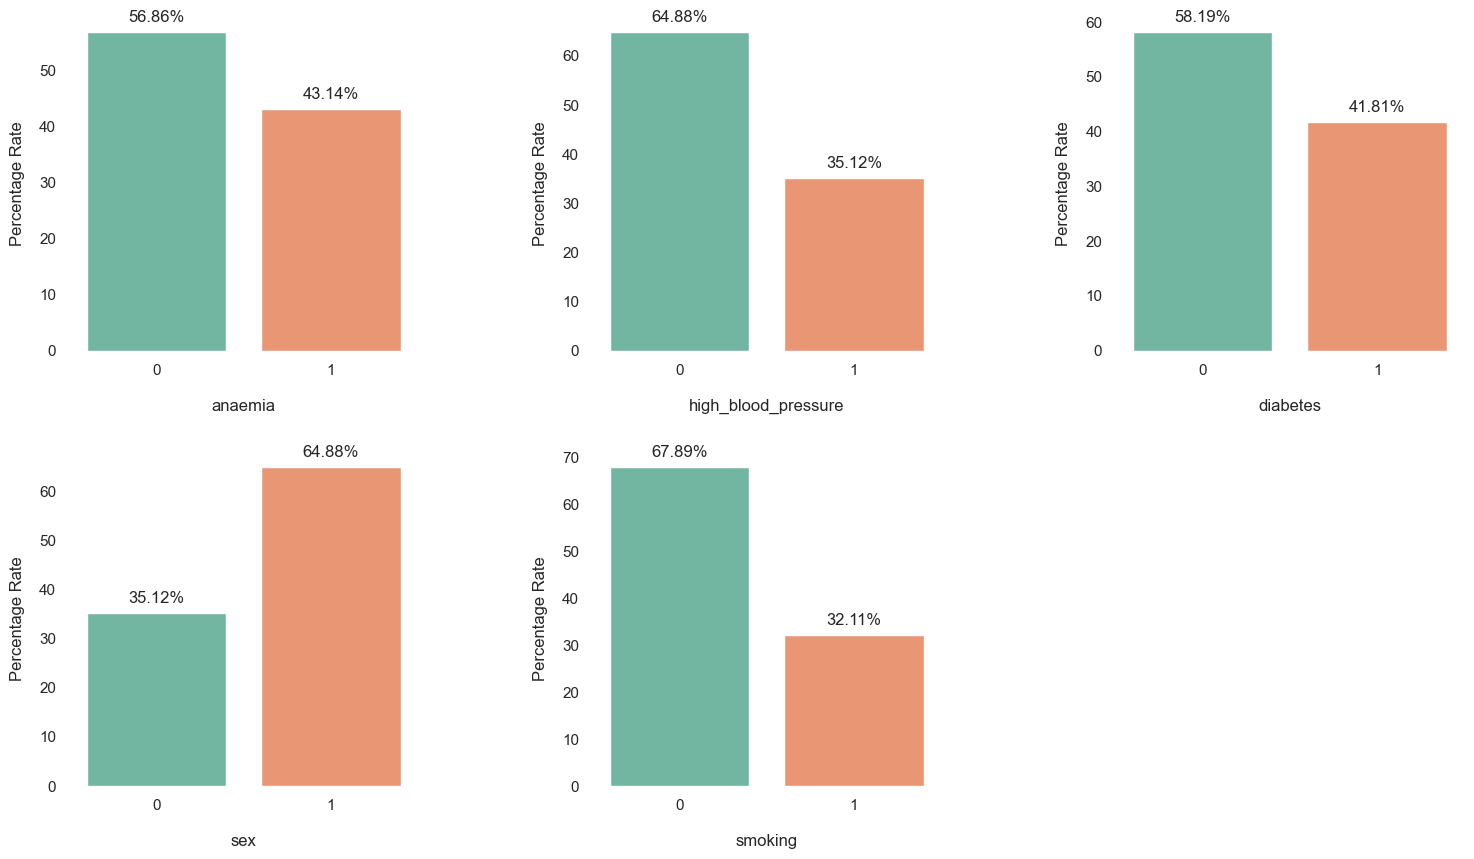

In [9]:
utils.plotUnivariateAnalysis(data_frame = heart_faliure_data, 
                             category_list = category_list, 
                             rows = 2, 
                             cols = 3,
                             figsize = (18, 10))

#### Distribution of Age

In [13]:
hist_data = [heart_faliure_data["age"].values]
group_labels = ['age']

utils.constructDistPlot(hist_data = hist_data, 
                        group_labels = group_labels, 
                        title_text = "Distribution of Age",
                        bin_size = [2, 2],
                        colors = ['rgb(0, 100, 0)'],
                        export_to_png = False)

#### Distribution of Age w.r.t. Gender

In [14]:
utils.constructNotchedBoxPlots(data_frame = heart_faliure_data,
                               x = 'sex',
                               y = 'age',
                               hover_name = 'sex', 
                               color = 'sex', 
                               title_text = 'Distribution of Age, Gender Wise - Male: 1, Female: 0',
                               export_to_png = False)

#### Effect of Age on Survival Rate

In [15]:
survived = heart_faliure_data[heart_faliure_data["DEATH_EVENT"] == 0]["age"]
not_survived = heart_faliure_data[heart_faliure_data["DEATH_EVENT"] == 1]["age"]

In [16]:
hist_data = [survived, not_survived]
group_labels = ['Survived', 'Not Survived']

utils.constructDistPlot(hist_data = hist_data, 
                        group_labels = group_labels, 
                        title_text = "Effect of Age on the Survival Rate",
                        bin_size = [1, 1],
                        export_to_png = False)

#### Platelets and Death Event - Box plot

In [17]:
utils.constructNotchedBoxPlots(data_frame = heart_faliure_data,
                               x = 'DEATH_EVENT',
                               y = 'platelets',
                               hover_name = 'DEATH_EVENT', 
                               color = 'DEATH_EVENT', 
                               title_text = 'Distribution of Platelets w.r.t Survival Rate',
                               export_to_png = False)

#### Distribution of Death Event

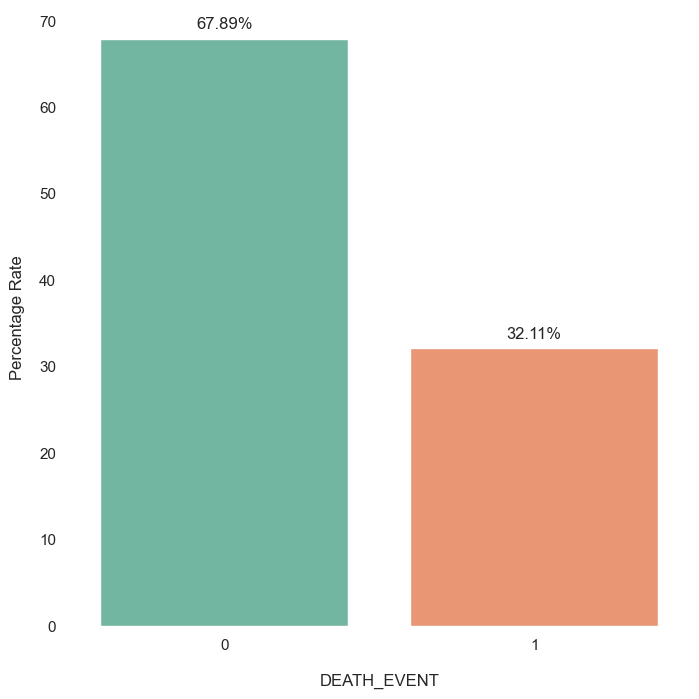

In [18]:
utils.plotUnivariateAnalysis(data_frame = heart_faliure_data, 
                             category_list = ['DEATH_EVENT'], 
                             rows = 1, 
                             cols = 1, 
                             figsize = (8, 8))

#### Data Correlation

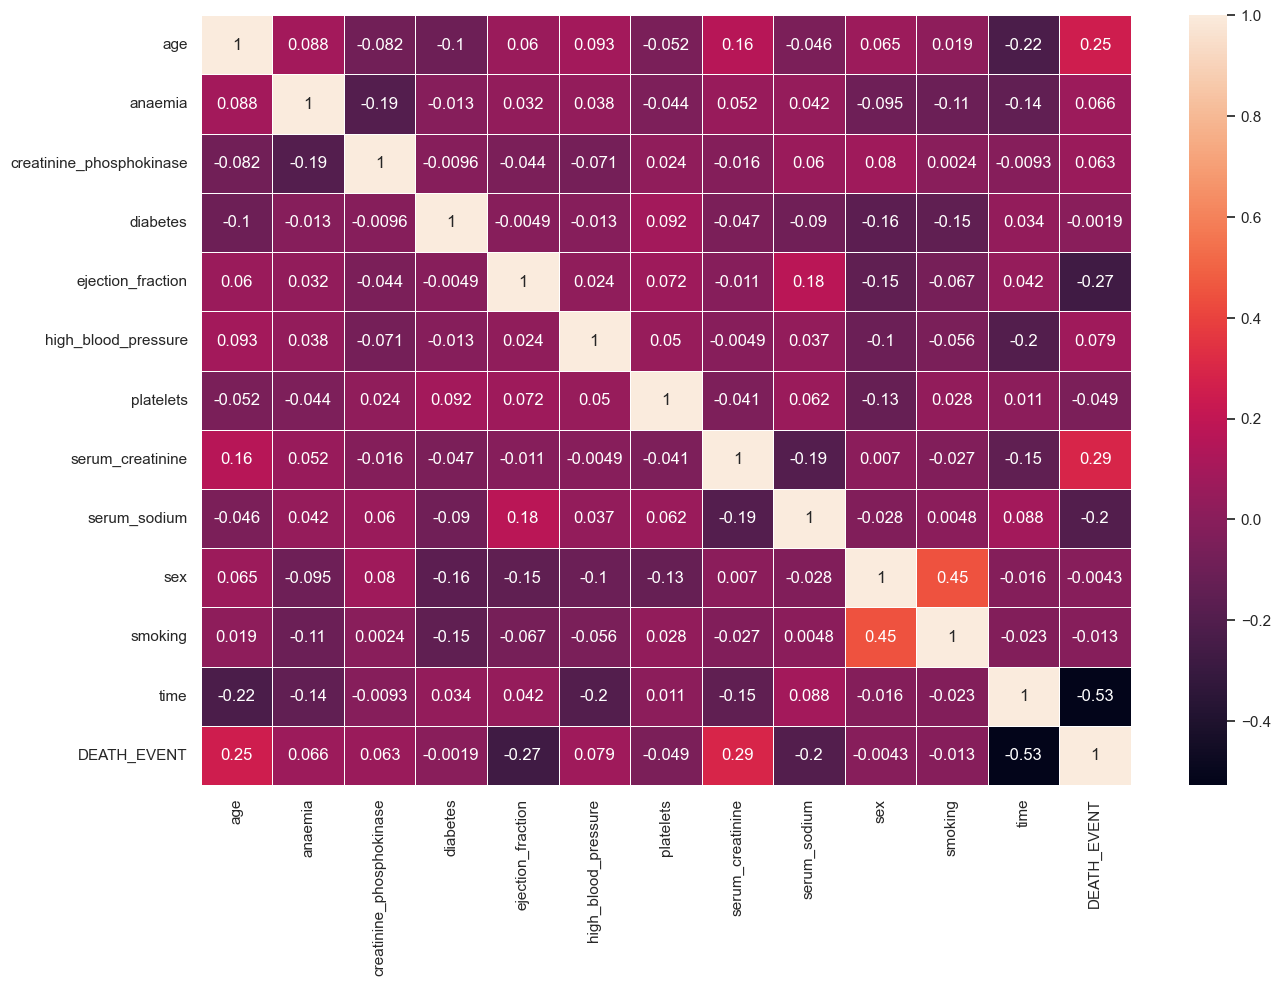

In [19]:
data_corr = utils.plotDataCorrelationHeatMap(heart_faliure_data)

#### Features most likely related to DEATH_EVENT

In [20]:
# we remove the DEATH_EVENT as it will have a 1 correlation value to itself.
data_corr[(data_corr['DEATH_EVENT'].abs() > 0.2) & (data_corr['DEATH_EVENT'].abs() != 1)]['DEATH_EVENT']

age                  0.253729
ejection_fraction   -0.268603
serum_creatinine     0.294278
time                -0.526964
Name: DEATH_EVENT, dtype: float64

### Kaplan Meier Estimates - Survival Analysis

In [23]:
from SurvivalAnalysisUtils import KaplanMeierUtils
kmUtils = KaplanMeierUtils()

categorical_columns = ['anaemia','diabetes', 'high_blood_pressure','sex','smoking']

continuous_columns = ['age','creatinine_phosphokinase','ejection_fraction', 
                      'platelets','serum_creatinine','serum_sodium','time']

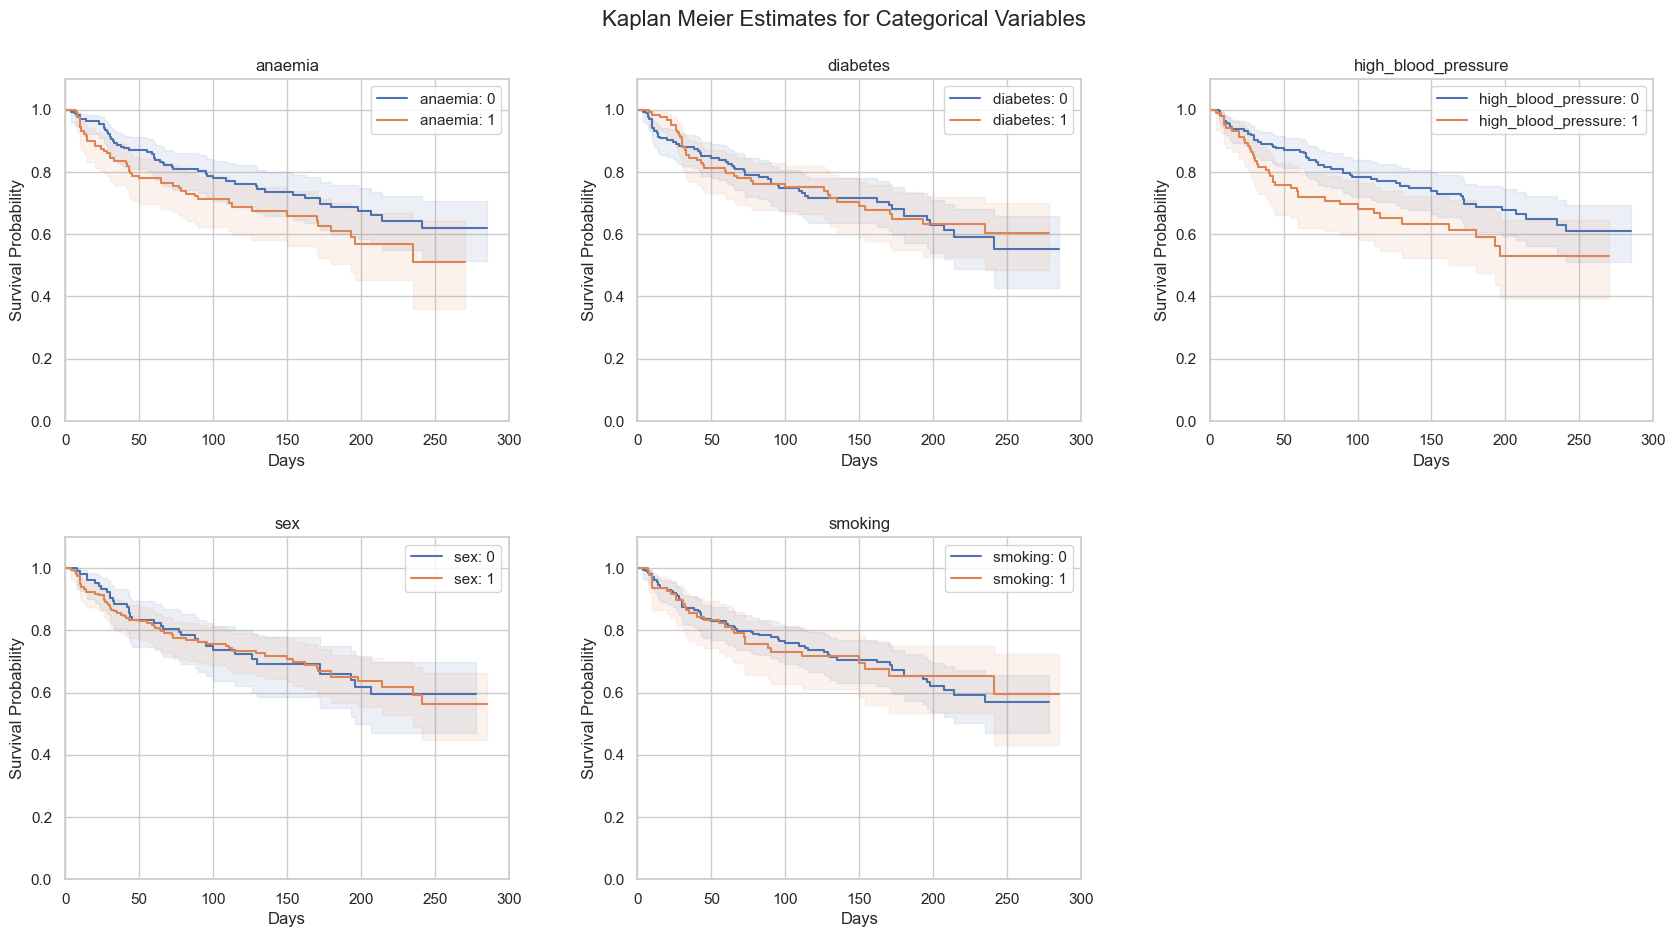

In [25]:
# Categorical Variables
kmUtils.PlotKaplanMeierEstimatesForCategoricalVariables(data=heart_faliure_data,
                                                        categorical_columns=categorical_columns)

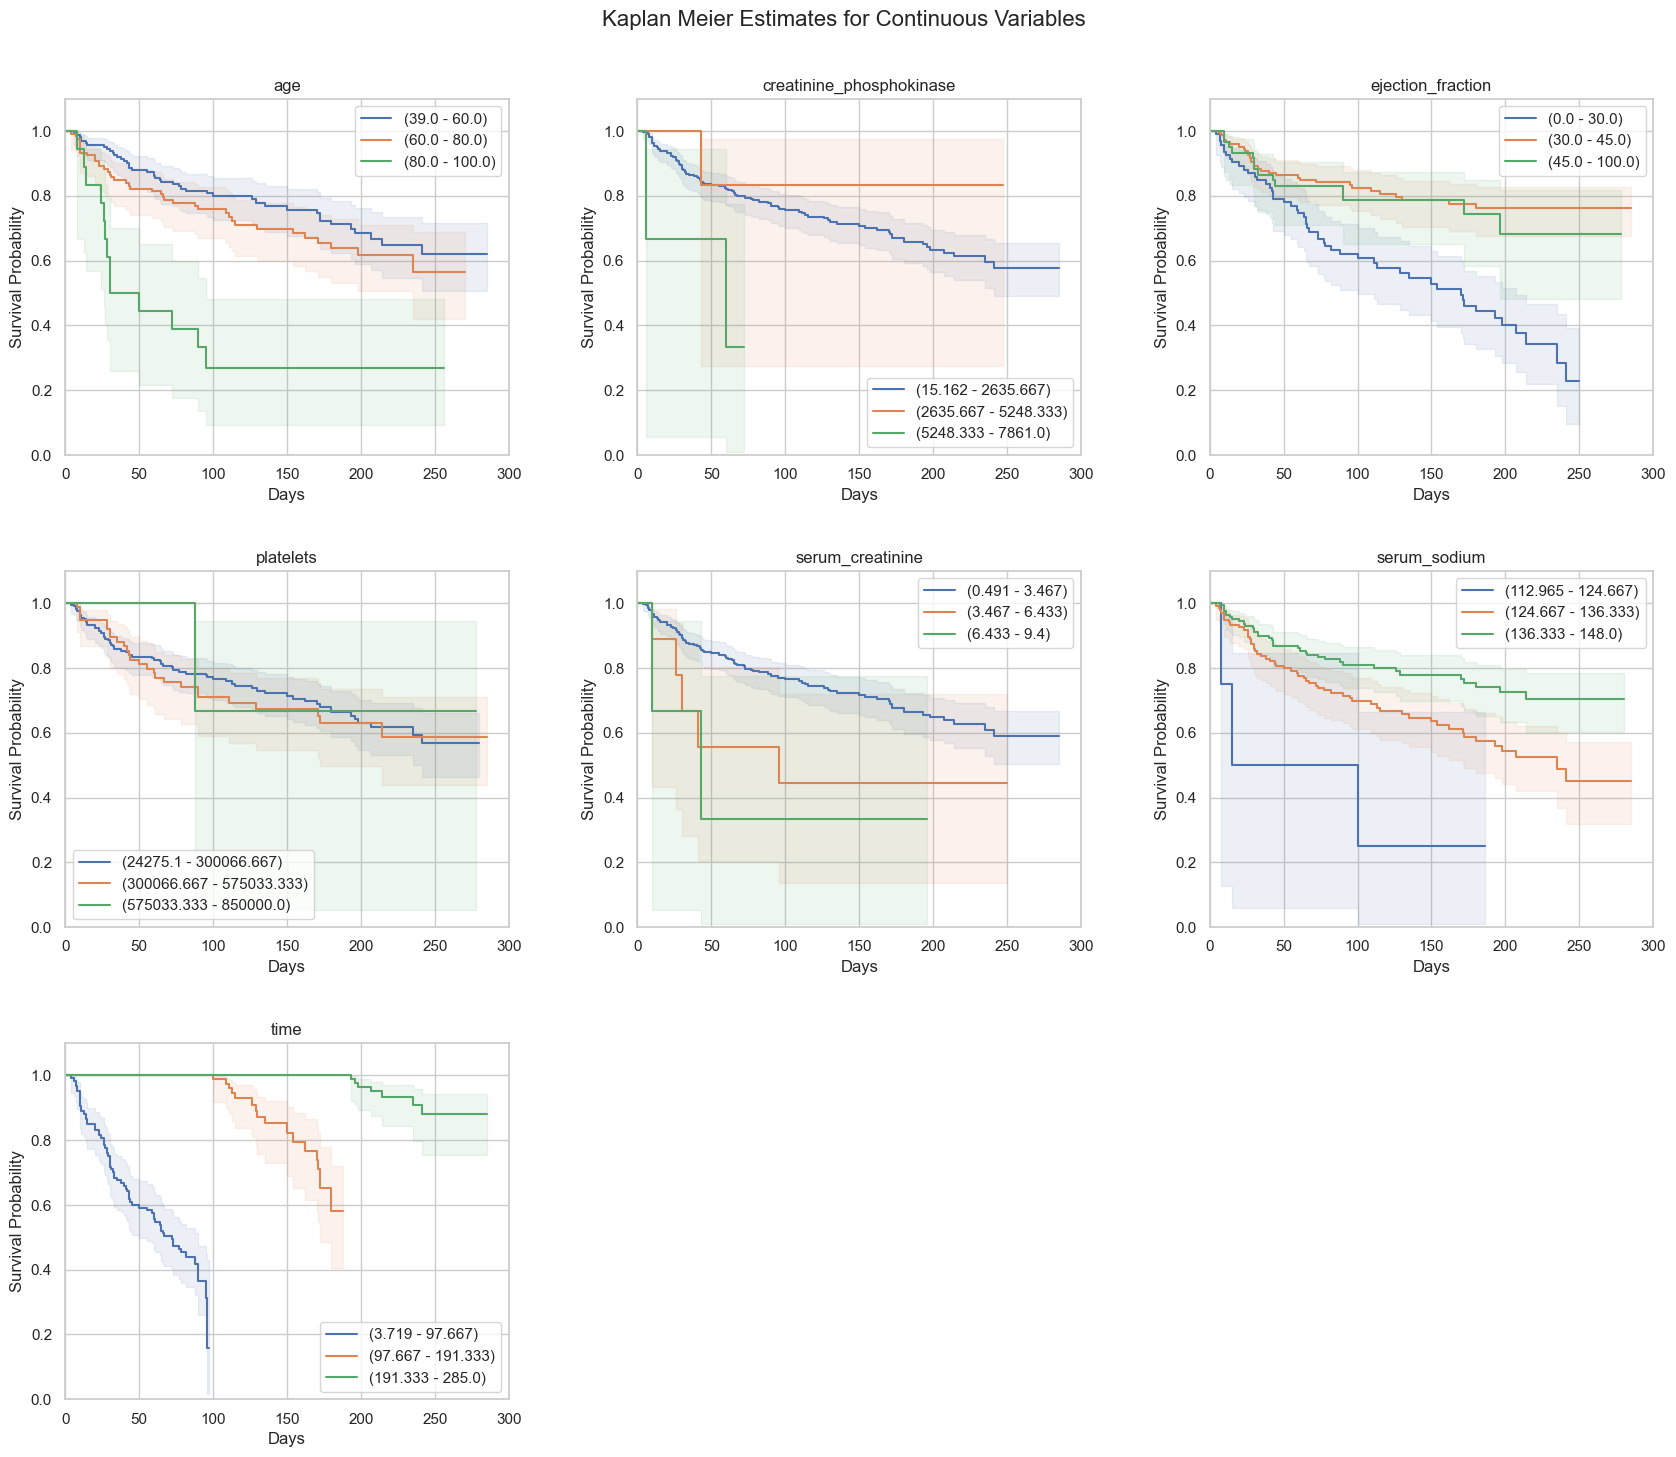

In [26]:
# Continuous Variables
kmUtils.PlotKaplanMeierEstimatesForContinuousVariables(data=heart_faliure_data,
                                                       continuous_columns=continuous_columns)

### Survival Expectancy Analysis - Cox Proportional Hazards Regression

In [27]:
from sklearn.model_selection import train_test_split
from lifelines import CoxPHFitter 

In [28]:
textIdxs = [42, 298, 5, 193, 179]

# extract the test data rows
test_set = heart_faliure_data.iloc[textIdxs]

#drop those rows from the train set
heart_faliure_data.drop(textIdxs, axis = 0, inplace=True)

heart_faliure_data.shape

(294, 13)

In [29]:
test_set['Patient'] = 'Patient - ' + test_set.index.astype(str)
test_set.set_index('Patient', drop = True, inplace = True)
test_set

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
Patient,,,,,,,,,,,,,
Patient - 42,70.0,0,571,1,45,1,185000.0,1.20,139,1,1,33,1
Patient - 298,50.0,0,196,0,45,0,395000.0,1.60,136,1,1,285,0
Patient - 5,90.0,1,47,0,40,1,204000.0,2.10,132,1,1,8,1
Patient - 193,73.0,1,231,1,30,0,160000.0,1.18,142,1,1,180,0
Patient - 179,55.0,0,835,0,40,0,279000.0,0.70,140,1,1,147,0


In [30]:
CoxFitter = CoxPHFitter(alpha=0.05)

In [31]:
CoxFitter.fit(heart_faliure_data, duration_col='time', 
              event_col='DEATH_EVENT',
              show_progress = True)

Iteration 1: norm_delta = 1.03e+00, step_size = 0.9500, log_lik = -496.52054, newton_decrement = 4.23e+01, seconds_since_start = 0.0
Iteration 2: norm_delta = 2.33e-01, step_size = 0.9500, log_lik = -466.04056, newton_decrement = 7.17e+00, seconds_since_start = 0.0
Iteration 3: norm_delta = 8.57e-02, step_size = 0.9500, log_lik = -458.11423, newton_decrement = 8.63e-01, seconds_since_start = 0.0
Iteration 4: norm_delta = 2.05e-02, step_size = 1.0000, log_lik = -457.15298, newton_decrement = 3.45e-02, seconds_since_start = 0.0
Iteration 5: norm_delta = 9.24e-04, step_size = 1.0000, log_lik = -457.11752, newton_decrement = 6.65e-05, seconds_since_start = 0.0
Iteration 6: norm_delta = 1.80e-06, step_size = 1.0000, log_lik = -457.11745, newton_decrement = 2.57e-10, seconds_since_start = 0.0
Convergence success after 6 iterations.


<lifelines.CoxPHFitter: fitted with 294 total observations, 200 right-censored observations>

<Axes: xlabel='log(HR) (95% CI)'>

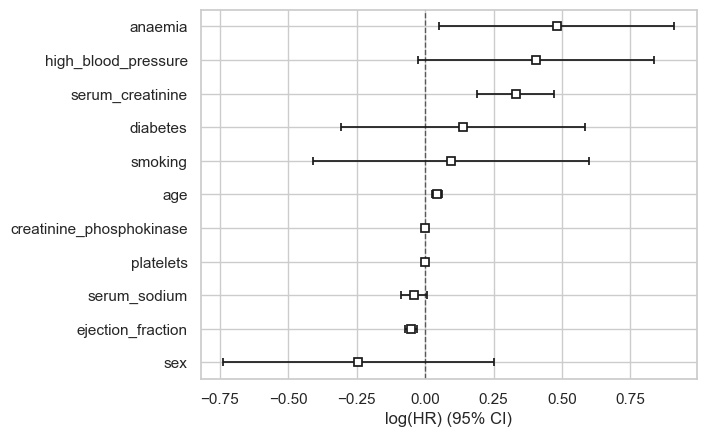

In [32]:
CoxFitter.plot()

<Axes: xlabel='HR (95% CI)'>

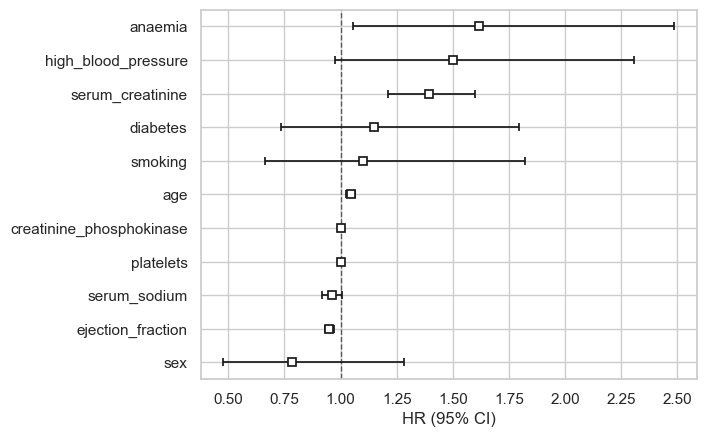

In [33]:
CoxFitter.plot(hazard_ratios = True)


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


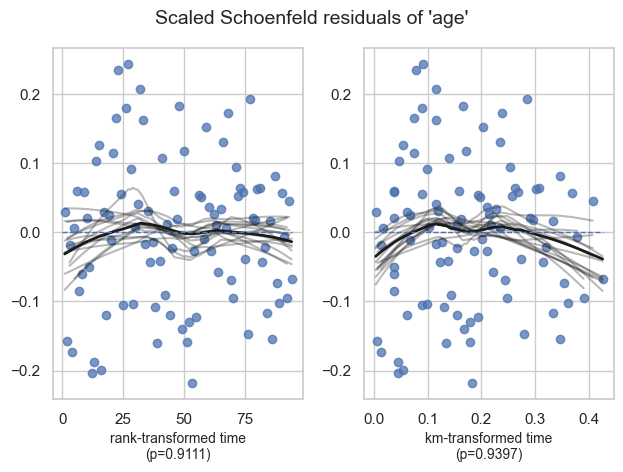

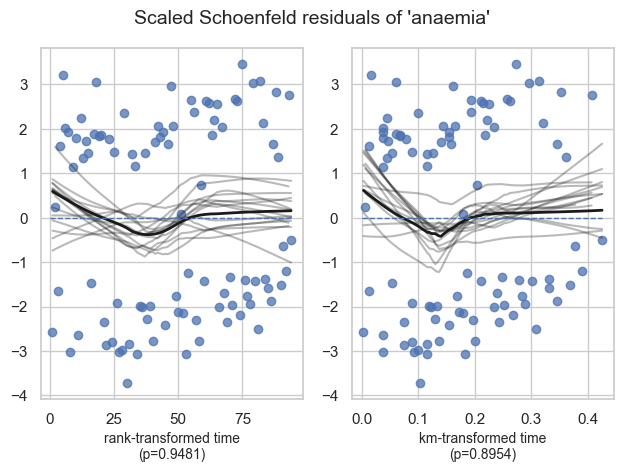

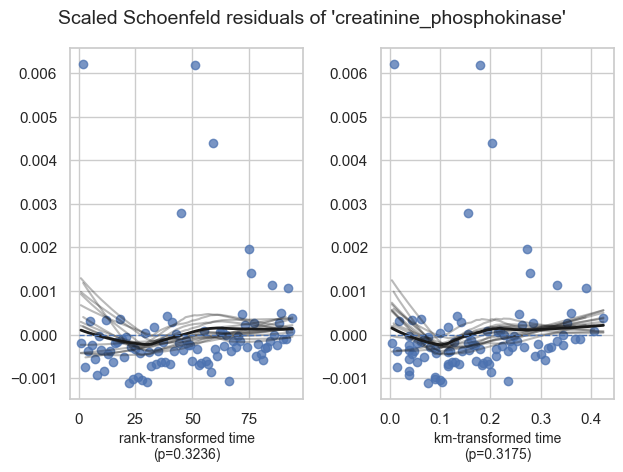

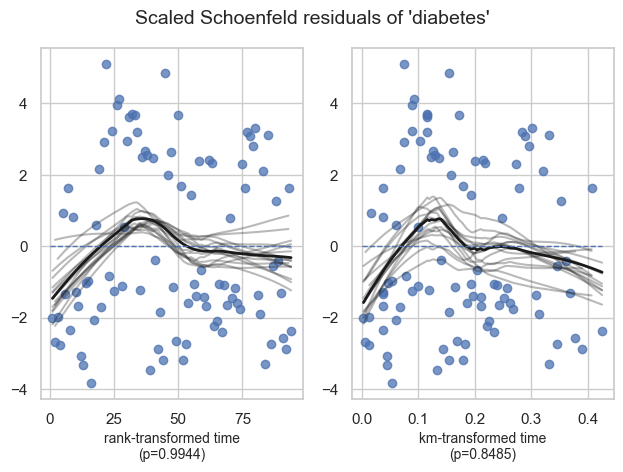

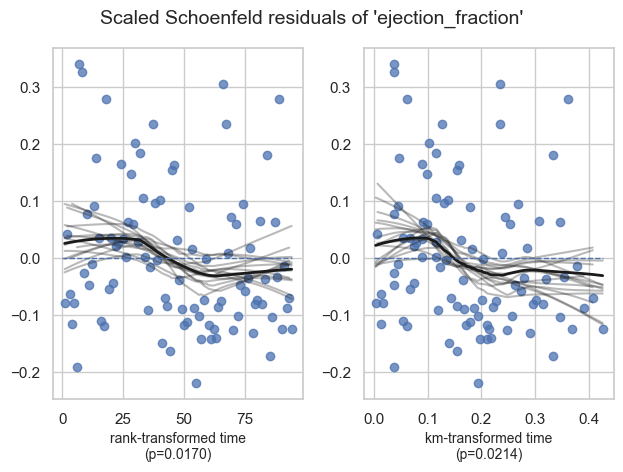

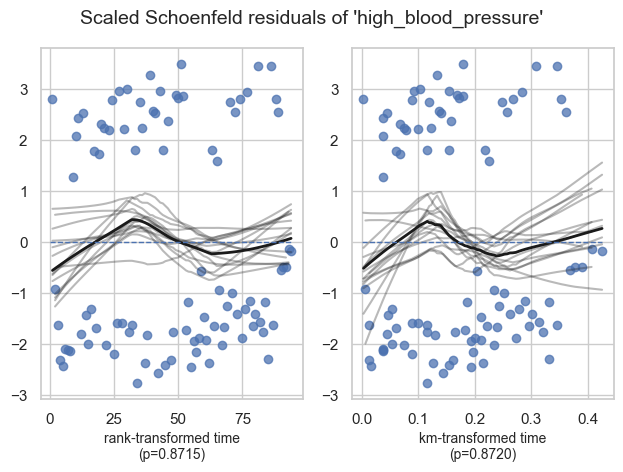

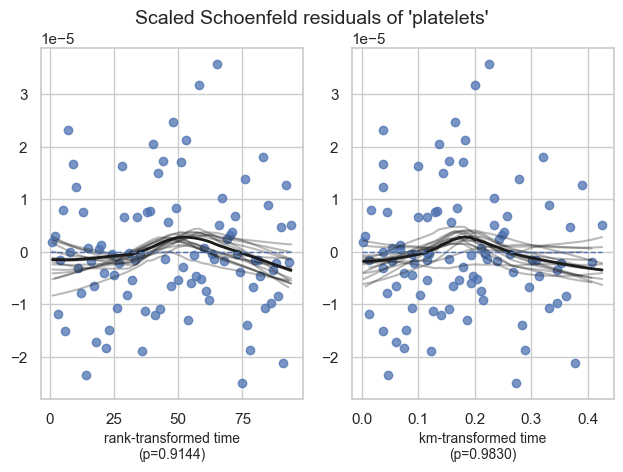

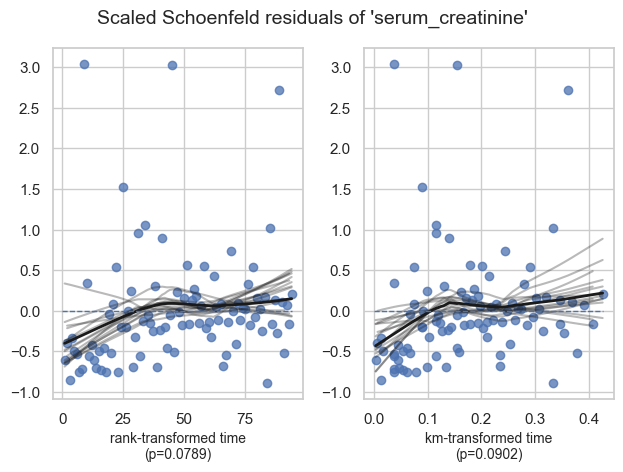

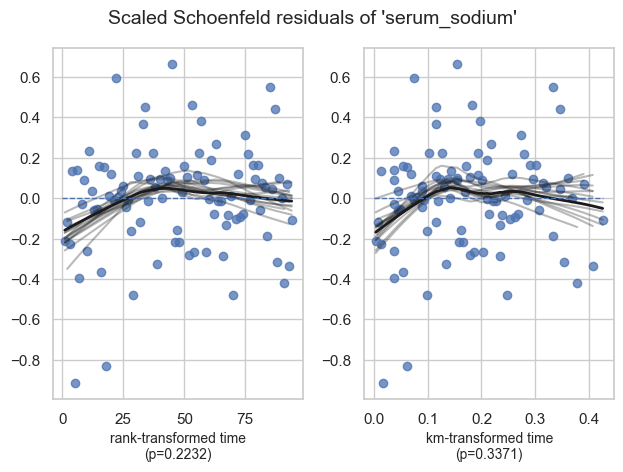

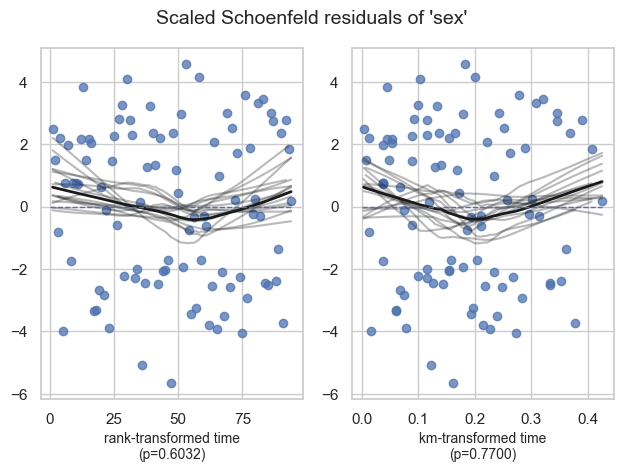

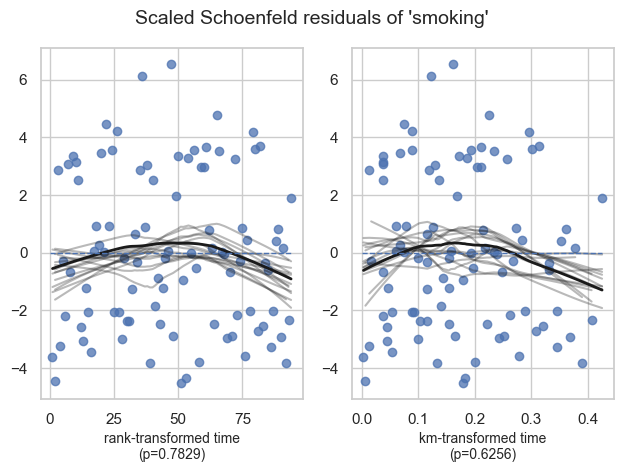

In [34]:
_ = CoxFitter.check_assumptions(heart_faliure_data, show_plots = True)

In [35]:
CoxFitter.print_summary(decimals=3)

<lifelines.CoxPHFitter: fitted with 294 total observations, 200 right-censored observations>
             duration col = 'time'
                event col = 'DEATH_EVENT'
      baseline estimation = breslow
   number of observations = 294
number of events observed = 94
   partial log-likelihood = -457.117
         time fit was run = 2026-03-28 00:15:40 UTC

---
                           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                  
age                       0.045     1.046     0.009           0.026           0.063               1.026               1.065
anaemia                   0.481     1.618     0.219           0.052           0.911               1.053               2.486
creatinine_phosphokinase  0.000     1.000     0.000           0.000           0.000               1.000               1.000
diabetes                  0.138     1.148     0.227          -0.308           0.584               0.735               1.793
ejection_fraction        -0.051     0.950     0.011          -0.072          -0.031               0.930               0.970
high_blood_pressure       0.406     1.500     0.219          -0.024           0.836               0.976               2.306
platelets                -0.000     1.000     0.000          -0.000           0.000               1.000               1.000
serum_creatinine          0.331     1.392     0.071           0.191           0.470               1.211               1.600
serum_sodium             -0.040     0.960     0.024          -0.087           0.006               0.917               1.006
sex                      -0.244     0.784     0.252          -0.738           0.250               0.478               1.284
smoking                   0.096     1.101     0.257          -0.408           0.600               0.665               1.822

                          cmp to      z       p  -log2(p)
covariate                                                
age                        0.000  4.714 <0.0005    18.654
anaemia                    0.000  2.198   0.028     5.159
creatinine_phosphokinase   0.000  2.275   0.023     5.449
diabetes                   0.000  0.606   0.545     0.877
ejection_fraction          0.000 -4.822 <0.0005    19.421
high_blood_pressure        0.000  1.849   0.064     3.955
platelets                  0.000 -0.282   0.778     0.362
serum_creatinine           0.000  4.646 <0.0005    18.175
serum_sodium               0.000 -1.695   0.090     3.474
sex                        0.000 -0.967   0.334     1.583
smoking                    0.000  0.372   0.710     0.495
---
Concordance = 0.740
Partial AIC = 936.235
log-likelihood ratio test = 78.806 on 11 df
-log2(p) of ll-ratio test = 38.536

#### Test Data - Survival Function for Individuals

In [36]:
# Predict the survival function for individuals, given their covariates. This assumes that the individual
# just entered the study (that is, we do not condition on how long they have already lived for.)
survival_function_data = CoxFitter.predict_survival_function(test_set)

# extract the head 10 and tail 10 for analysis...
head = survival_function_data.head(10)
tail = survival_function_data.tail(10)

utils.display_dataframe_side_by_side(dataframes = [head, tail], 
                                     table_captions = ['First 10 days...<br></br>', 'Last 10 days...<br></br>'], 
                                     master_caption = 'Survival Probabilities over a time period of 280 days...',
                                     tablespacing = 15)

Survival Probabilities over a time period of 280 days...

,Patient - 42,Patient - 298,Patient - 5,Patient - 193,Patient - 179
4.000000,0.998049,0.999487,0.986352,0.995726,0.999371
6.000000,0.996077,0.998968,0.972722,0.991416,0.998735
7.000000,0.992129,0.997926,0.945912,0.982817,0.997458
8.000000,0.990145,0.997402,0.932683,0.978512,0.996815
10.000000,0.978008,0.994176,0.855153,0.952398,0.992863
11.000000,0.973273,0.992909,0.826442,0.942314,0.991313
12.000000,0.973273,0.992909,0.826442,0.942314,0.991313
13.000000,0.970899,0.992272,0.812365,0.937281,0.990533
14.000000,0.966155,0.990996,0.784839,0.927264,0.988972
15.000000,0.961395,0.989712,0.758036,0.917276,0.987400


<Axes: title={'center': 'Survival Function for Individuals'}, xlabel='No. of Days', ylabel='Survival Function'>

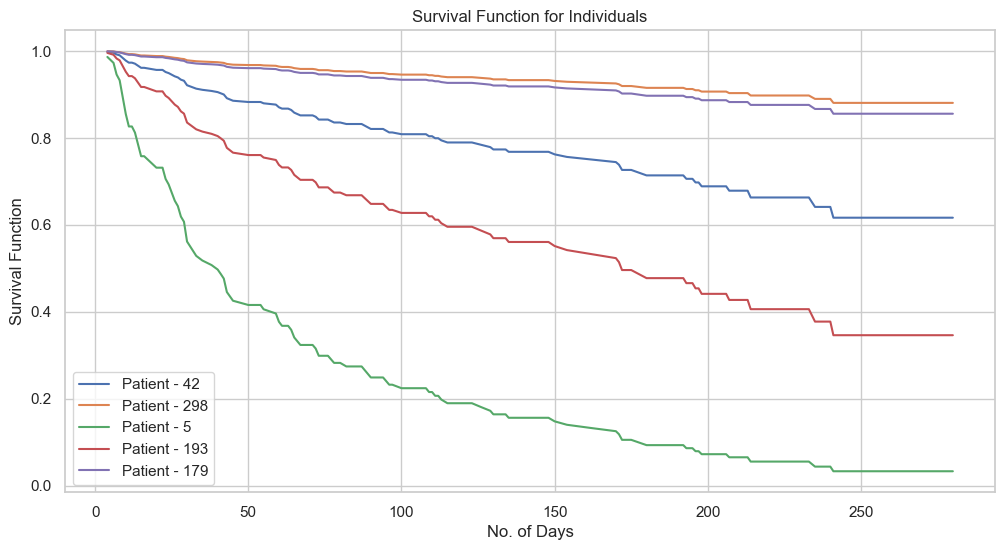

In [37]:
survival_function_data.plot(figsize=(12, 6), 
                            title = "Survival Function for Individuals", 
                            xlabel = "No. of Days", 
                            ylabel = "Survival Function")

### Heart Failure Prediction

In [40]:
# Import the required libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import recall_score, accuracy_score, confusion_matrix, f1_score, matthews_corrcoef
from sklearn.metrics import precision_score, auc, roc_auc_score, roc_curve, precision_recall_curve, classification_report
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

from scipy.stats import randint 

from imblearn.over_sampling import SMOTE
from collections import Counter

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

In [41]:
# X = heart_faliure_data[['age', 'ejection_fraction', 'serum_creatinine', 'serum_sodium', 
#  'creatinine_phosphokinase']]

# X = heart_faliure_data[['age', 'ejection_fraction','serum_creatinine', 'serum_sodium']] 

X = heart_faliure_data[['ejection_fraction', 'serum_creatinine', 'age']]

# X = heart_faliure_data[['age','ejection_fraction','serum_sodium']]

y = heart_faliure_data[['DEATH_EVENT']]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.90, test_size = 0.10, random_state = 109)

print("X_Train Shape:", X_train.shape)
print("Y_Train Shape:", y_train.shape)
print("X_Test Shape:", X_test.shape)
print("Y_Test Shape:", y_test.shape)

X_Train Shape: (264, 3)
Y_Train Shape: (264, 1)
X_Test Shape: (30, 3)
Y_Test Shape: (30, 1)


In [42]:
print('Original dataset shape %s' % Counter(y_train.values.ravel()))

Original dataset shape Counter({0: 181, 1: 83})


In [43]:
data_features = dict(enumerate(X.columns))
data_features

{0: 'ejection_fraction', 1: 'serum_creatinine', 2: 'age'}

In [44]:
# Implement SMOTE
sampling = SMOTE(random_state = 100)
X_train, y_train = sampling.fit_resample(X_train.values, y_train.values.ravel())
    
# Shuffle the data
perms = np.random.permutation(X_train.shape[0])
X_train = X_train[perms]
y_train = y_train[perms]

X_train = pd.DataFrame(data = X_train)
y_train = pd.DataFrame(data = y_train)

print(X_train.shape)
print(y_train.shape)

(362, 3)
(362, 1)


In [45]:
print('Resampled dataset shape %s' % Counter(y_train.values.ravel()))
print('Test dataset shape %s' % Counter(y_test.values.ravel()))

Resampled dataset shape Counter({0: 181, 1: 181})
Test dataset shape Counter({0: 19, 1: 11})


In [46]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

#### SVM with RBF Kernel

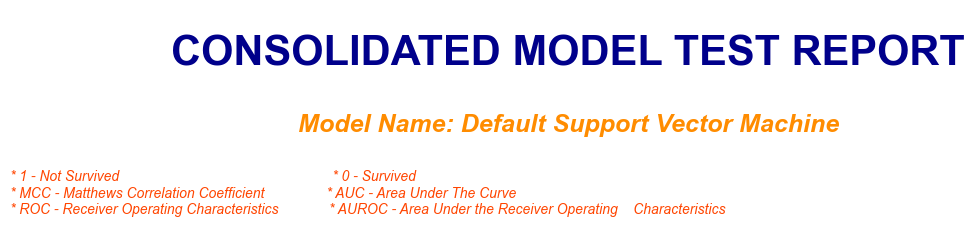

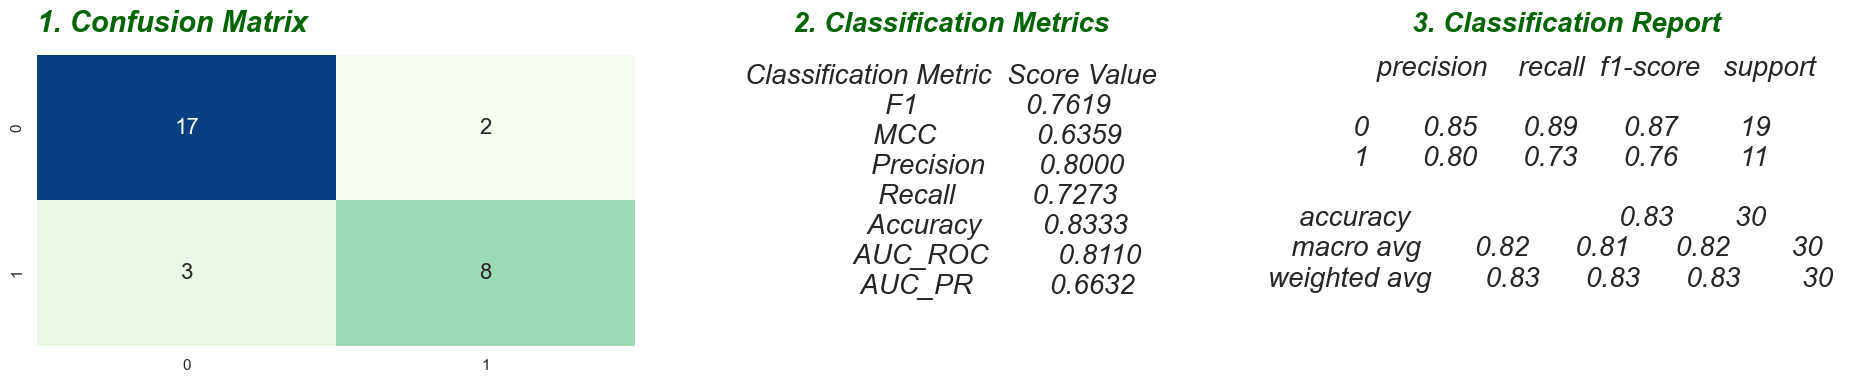

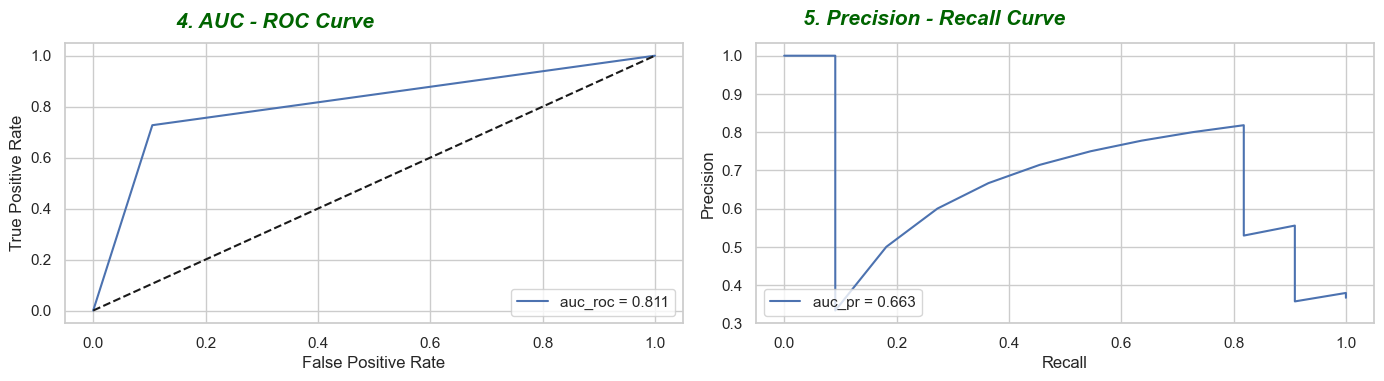

In [47]:
# SVM with Default Parameters and probability = True

svm = SVC(kernel = 'rbf', probability = True, random_state = 100)

svm = svm.fit(X_train, y_train.values.ravel())

# Generate the model test classification report
utils.Generate_Model_Test_Classification_Report(svm, X_test, y_test, model_name="Default Support Vector Machine")

In [48]:
# GridSearchCV to find best parameters for svm
svm = SVC(kernel = 'rbf', probability = True, random_state = 100)

# parameters to build the model on
param_grid = {'C': [0.1, 1, 10, 100, 1000],  
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001]}  

grid_search = GridSearchCV(estimator = svm, param_grid = param_grid, 
                  scoring = 'accuracy', n_jobs = -1, cv = 5, verbose = 2)

# fitting the model for grid search 
grid_search.fit(X_train, y_train.values.ravel())
    
# get the best parameter from gird search 
print("Best Parameters:", grid_search.best_params_) 
  
# get the best classifier model after hyper-parameter tuning 
print("\nBest Classifier:", grid_search.best_estimator_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END ..................................C=0.1, gamma=0.01; total time=   0.0s
[CV] END ..................................C=0.1, gamma=0.01; total time=   0.0s
[CV] END ..................................C=0.1, gamma=0.01; total time=   0.0s
[CV] END .................................C=0.1, gamma=0.001; total time=   0.0s
[CV] END .................................C=0.1, gamma=0.001; total time=   0.0s
[CV] END .................................C=0.1, gamma=0.001; total time=   0.0s
[CV] END .................................C=0.1, gamma=0.001; total time=   0.0s
[CV] END .................................C=0.1, gamma=0.001; total time=   0.0s
[CV] END ................................C=0.1, gamma=0.0001; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END ................................C=0.1,

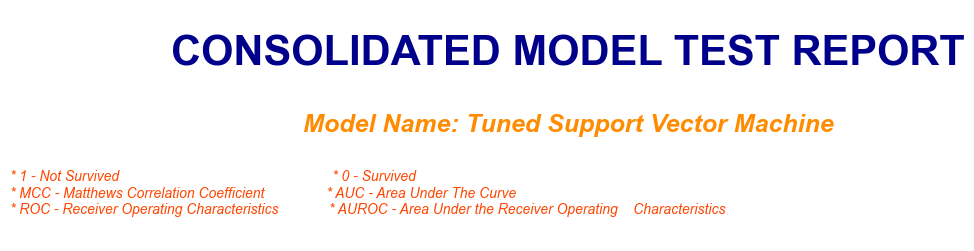

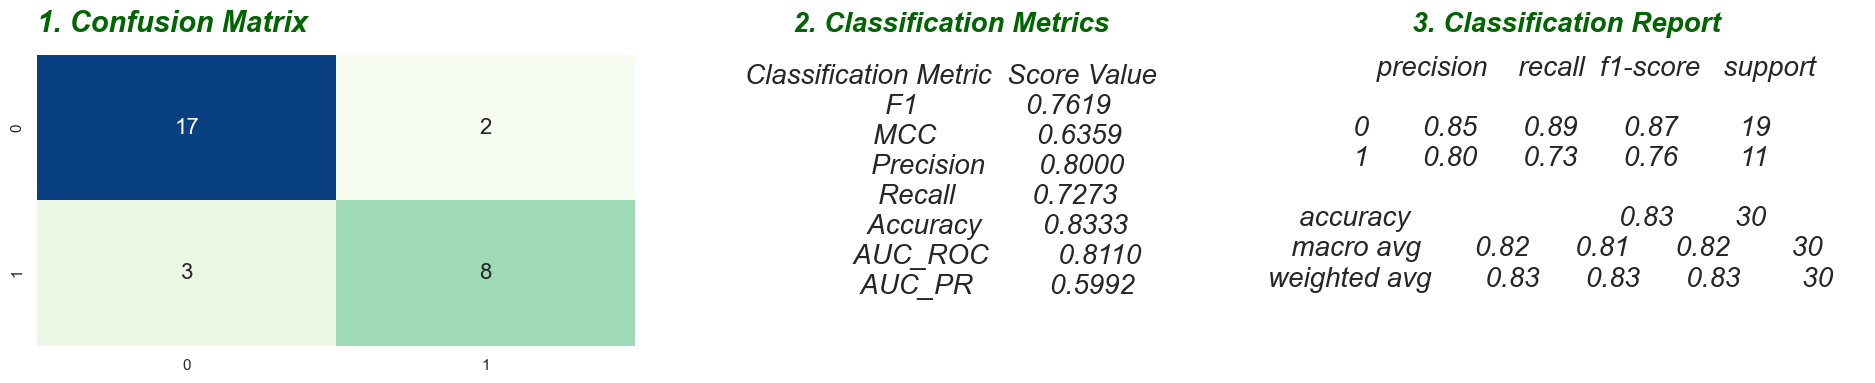

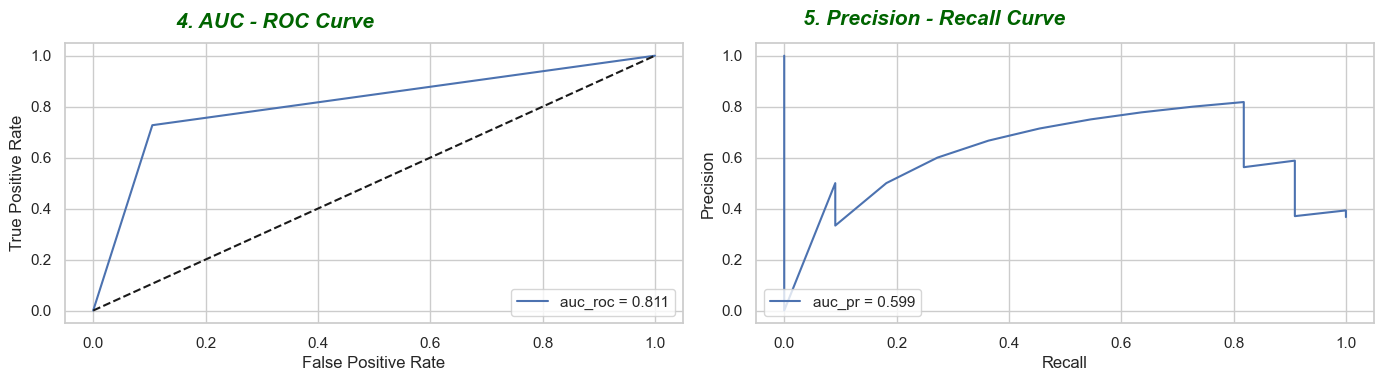

In [49]:
best_svc = grid_search.best_estimator_

best_svc.fit(X_train, y_train.values.ravel())


# Generate the model test classification report
utils.Generate_Model_Test_Classification_Report(best_svc, X_test, y_test, model_name="Tuned Support Vector Machine")

#### Decision Tree

In [50]:
# GridSearchCV to find the optimal tree parameters
tree = DecisionTreeClassifier(random_state = 100)

# parameters to build the model on
param_grid = {"max_depth": range(1, 30), 
#               "max_features": randint(1, 9), 
              "min_samples_leaf": randint(1, 9),
              "min_samples_split":range(2, 10),
              "criterion": ["gini", "entropy"]}

# Instantiating RandomizedSearchCV object 
tree_grid = RandomizedSearchCV(tree, param_grid, cv = 5) 
    
# fitting the model for grid search 
tree_grid.fit(X_train, y_train.values.ravel())
    
# get the best parameter from gird search 
print("Best Parameters:", tree_grid.best_params_) 
  
# get the best classifier model after hyper-parameter tuning 
print("\nBest Classifier:", tree_grid.best_estimator_) 

Best Parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 3, 'min_samples_split': 7}

Best Classifier: DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=3,
                       min_samples_split=7, random_state=100)


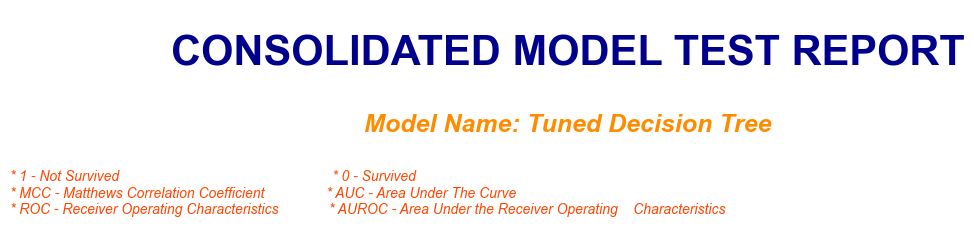

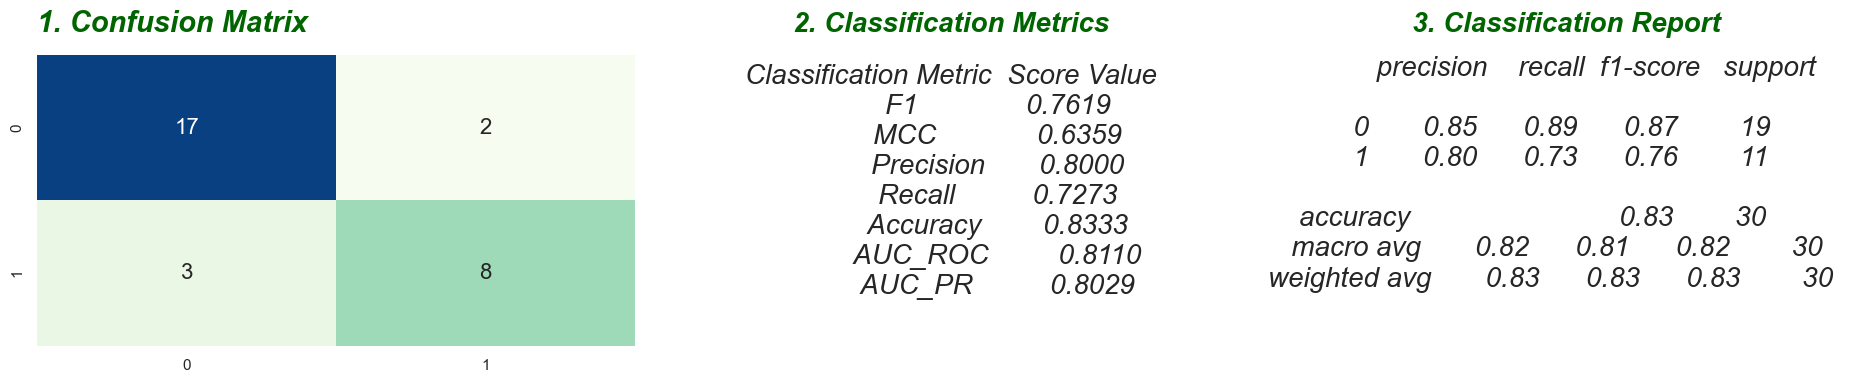

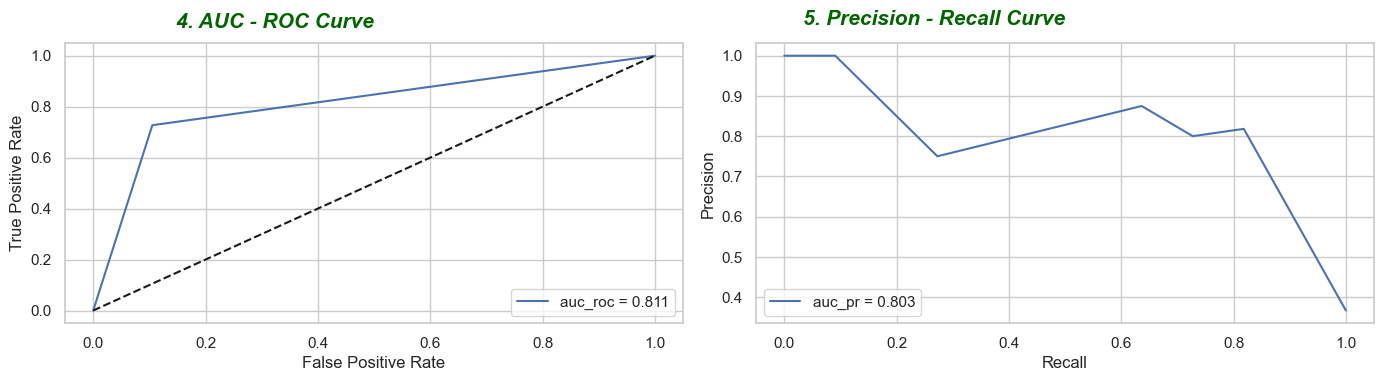

In [51]:
best_tree = tree_grid.best_estimator_

best_tree = best_tree.fit(X_train, y_train.values.ravel())

# Generate the model test classification report
utils.Generate_Model_Test_Classification_Report(best_tree, X_test, y_test, model_name="Tuned Decision Tree")

#### Random Forest

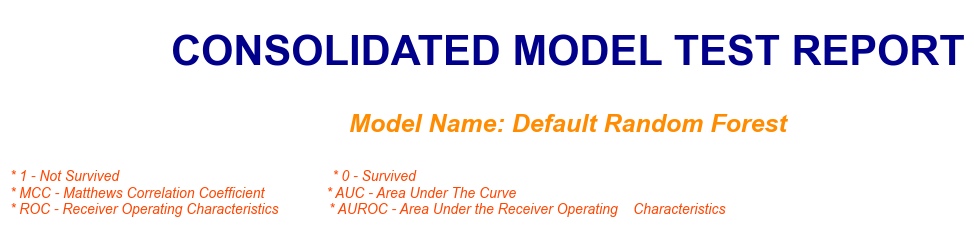

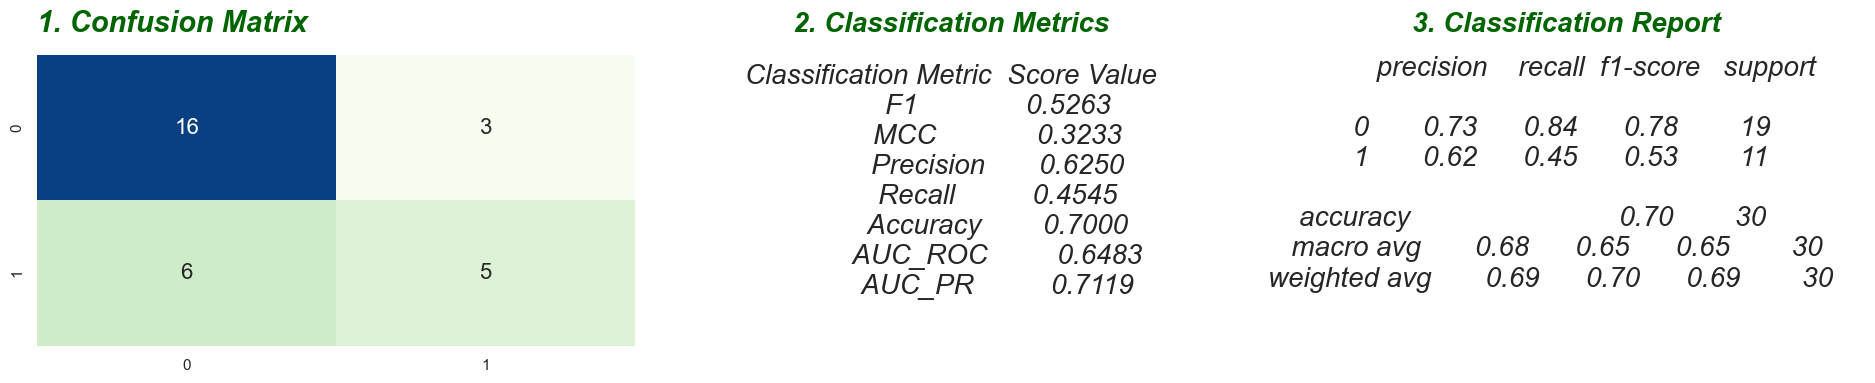

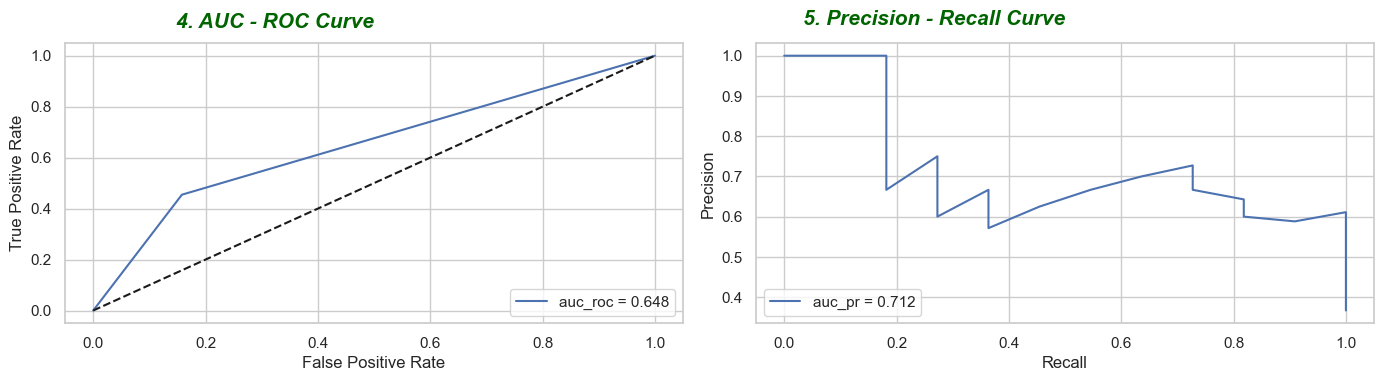

In [52]:
# Random Forest with Default Parameters
rfc = RandomForestClassifier(n_jobs = -1, random_state = 100)

rfc = rfc.fit(X_train, y_train.values.ravel())

# Generate the model test classification report
utils.Generate_Model_Test_Classification_Report(rfc, X_test, y_test, model_name="Default Random Forest")

In [53]:
rn_forest = RandomForestClassifier(n_jobs = -1, random_state = 100)

# parameters to build the model on
param_grid = {"max_depth": range(1, 10), 
#               "max_features": randint(1, 3), 
              "min_samples_leaf": randint(25, 50),
              "min_samples_split":range(50, 100, 2),
              "n_estimators": range(1000, 8000, 500),
              "bootstrap": [True, False]}

# Instantiating RandomizedSearchCV object 
forest_grid = RandomizedSearchCV(rn_forest, param_grid, cv = 5) 
    
# fitting the model for grid search 
forest_grid.fit(X_train, y_train.values.ravel())
    
# get the best parameter from gird search 
print("Best Parameters:", forest_grid.best_params_) 
  
# get the best classifier model after hyper-parameter tuning 
print("\nBest Classifier:", forest_grid.best_estimator_)

Best Parameters: {'bootstrap': False, 'max_depth': 6, 'min_samples_leaf': 49, 'min_samples_split': 86, 'n_estimators': 6500}

Best Classifier: RandomForestClassifier(bootstrap=False, max_depth=6, min_samples_leaf=49,
                       min_samples_split=86, n_estimators=6500, n_jobs=-1,
                       random_state=100)


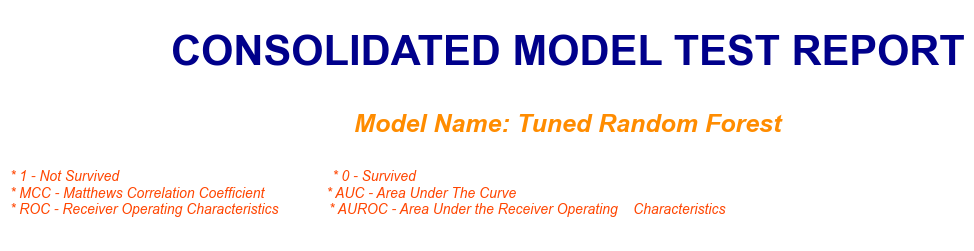

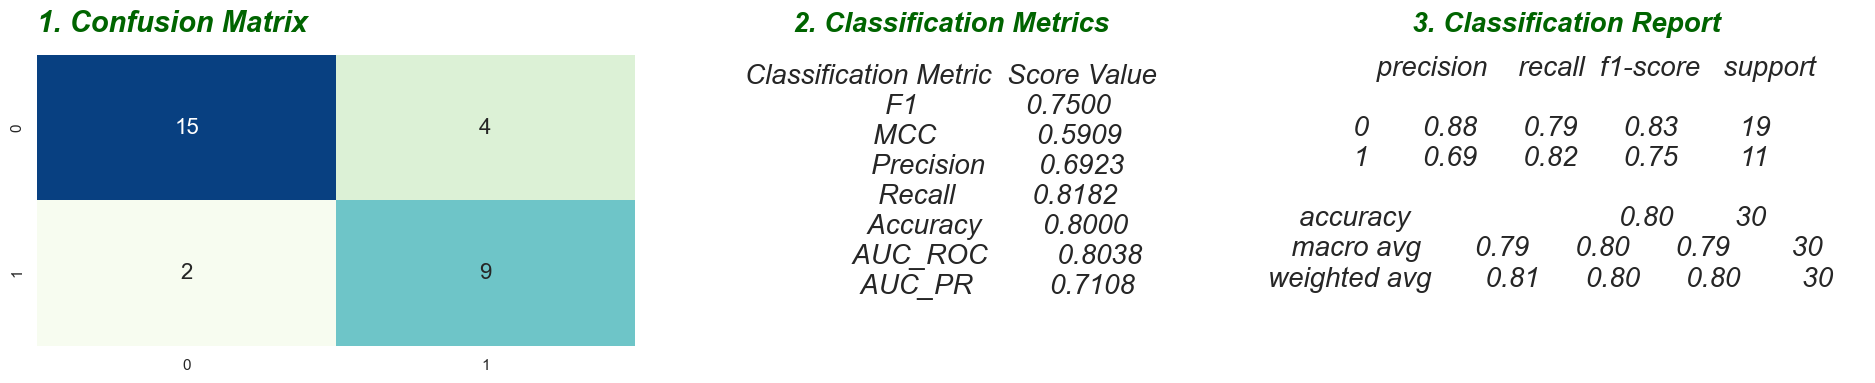

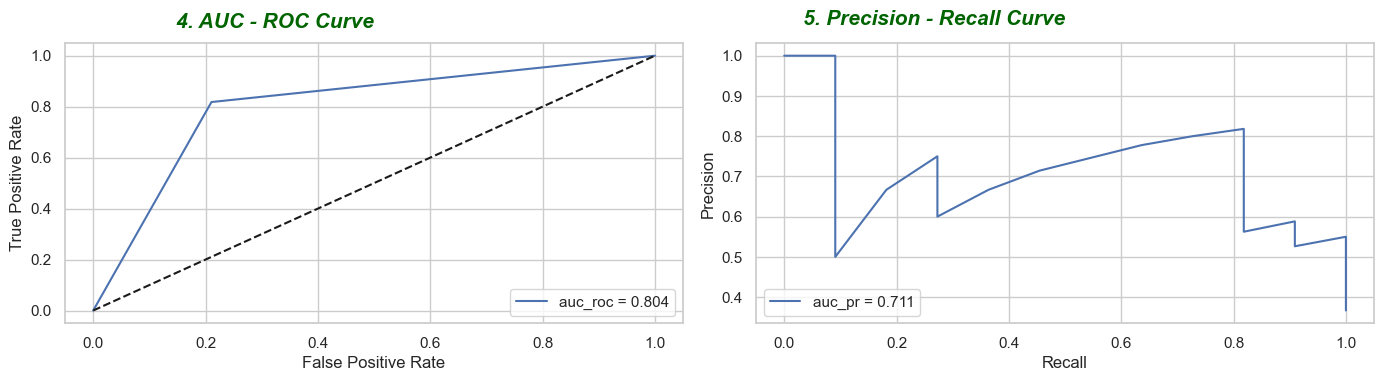

In [54]:
# Random Forest with Best Hypertuned Parameters
best_forest = forest_grid.best_estimator_

best_forest = best_forest.fit(X_train, y_train.values.ravel())

# Generate the model test classification report
utils.Generate_Model_Test_Classification_Report(best_forest, X_test, y_test, model_name="Tuned Random Forest")